   Individual   D3S1358   D8S1179    D21S11       FGA    TH01
0   Suspect 1  (14, 15)  (11, 13)  (29, 30)  (25, 25)  (8, 7)
1   Suspect 2  (14, 14)  (13, 13)  (30, 27)  (24, 23)  (7, 6)
2   Suspect 3  (13, 15)  (14, 12)  (28, 28)  (24, 25)  (6, 9)
3   Suspect 4  (13, 13)  (11, 14)  (27, 27)  (23, 23)  (8, 7)
4   Suspect 5  (15, 15)  (14, 14)  (29, 28)  (23, 24)  (8, 9)
5   Suspect 6  (15, 12)  (13, 11)  (29, 29)  (25, 21)  (8, 7)
6   Suspect 7  (15, 12)  (14, 12)  (28, 28)  (21, 22)  (6, 7)
7   Suspect 8  (15, 15)  (13, 14)  (29, 30)  (25, 23)  (7, 6)
8   Suspect 9  (15, 13)  (14, 14)  (28, 28)  (22, 24)  (7, 6)
9  Suspect 10  (14, 13)  (12, 14)  (28, 28)  (24, 24)  (6, 7)
Random Match Probability (RMP) for crime scene profile: 0.000008


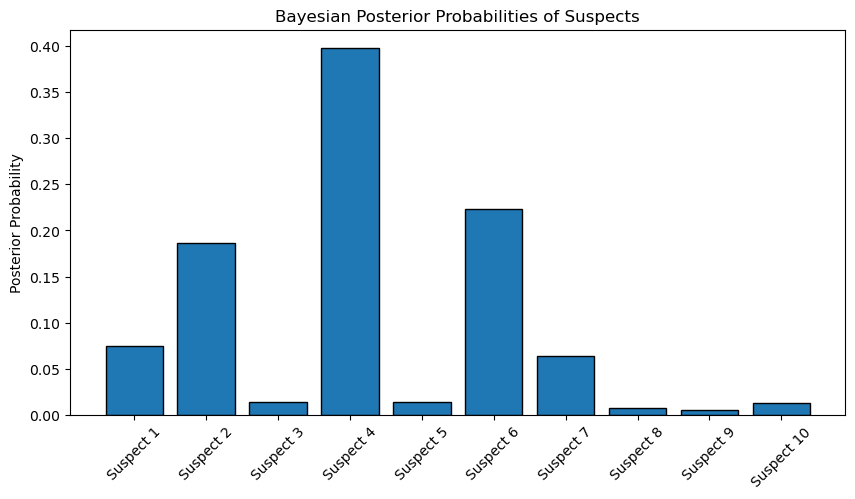

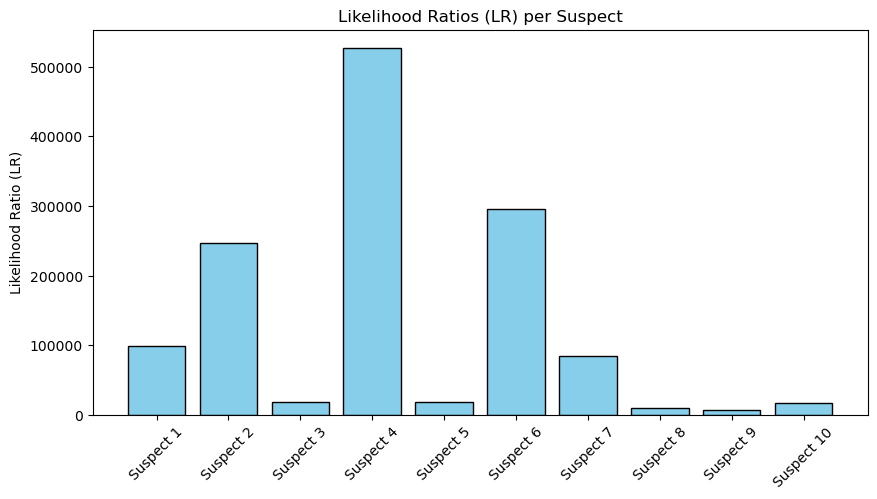


Final Table:

Most Probable Suspect:
Individual           Suspect 4
D3S1358               (13, 13)
D8S1179               (11, 14)
D21S11                (27, 27)
FGA                   (23, 23)
TH01                    (8, 7)
RMP                   0.000002
LR               526748.971193
Posterior_num     52674.897119
Posterior             0.397924
Name: 3, dtype: object


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## DNA Profile Simulation

np.random.seed(42)

### STR loci
loci = ["D3S1358","D8S1179","D21S11","FGA","TH01"]

### Number of suspects
num_suspects = 10

# Allele ranges for each locus (realistic STR alleles)
allele_ranges = {
    "D3S1358": list(range(12,16)),
    "D8S1179": list(range(11,15)),
    "D21S11": list(range(27,31)),
    "FGA": list(range(21,26)),
    "TH01": list(range(6,10))
}

### Generate genotypes
data = []
for s in range(1,num_suspects+1):
    geno = []
    for locus in loci:
        a1 = np.random.choice(allele_ranges[locus])
        a2 = np.random.choice(allele_ranges[locus])
        geno.append((a1, a2))
    data.append([f"Suspect {s}"] + geno)

### Create DataFrame
df_str = pd.DataFrame(data, columns=["Individual"] + loci)
print(df_str)

## Generate crime scene profile
crime_scene = {}
for locus in loci:
    a1 = np.random.choice(allele_ranges[locus])
    a2 = np.random.choice(allele_ranges[locus])
    crime_scene[locus] = (a1, a2)

crime_df = pd.DataFrame([crime_scene])
crime_df.index = ["Crime Scene"]
crime_df

## Flatten alleles for frequency calculation
## Allele Frequency Estimation and Random Match Probability (RMP)
###### Allele frequencies are estimated from simulated population data under Hardy-Weinberg assumptions.

allele_freqs = {}
for locus in loci:
    alleles = []
    for g in df_str[locus]:
        a1, a2 = g
        alleles.extend([a1, a2])
    counts = pd.Series(alleles).value_counts()
    freqs = counts / counts.sum()
    allele_freqs[locus] = freqs.to_dict()

# Function to get genotype probability
def genotype_prob(locus, genotype):
    a1, a2 = genotype
    freqs = allele_freqs[locus]
    EPS = 1e-6
    p1 = freqs.get(a1, EPS)
    p2 = freqs.get(a2, EPS)
    if a1 == a2:  # homozygous
        return p1**2
    else:  # heterozygous
        return 2 * p1 * p2

# Calculate RMP for crime scene profile
rmp = 1
for locus in loci:
    rmp *= genotype_prob(locus, crime_scene[locus])

print(f"Random Match Probability (RMP) for crime scene profile: {rmp:.6f}")

# ----------------------------
# STEP 1: Compute RMP for each suspect
# ----------------------------

def compute_rmp_for_individual(row):
    prob = 1
    for locus in loci:
        genotype = row[locus]
        
        # if stored as string "(a,b)" → parse
        if isinstance(genotype, str):
            a1, a2 = map(int, genotype.strip("()").split(","))
        else:
            a1, a2 = genotype
        
        prob *= genotype_prob(locus, (a1, a2))
    
    return prob

# Apply to dataframe
df = df_str.copy()
df["RMP"] = df.apply(compute_rmp_for_individual, axis=1)

# ----------------------------
# STEP 2: Likelihood Ratio (LR)
# ----------------------------
df["LR"] = 1 / df["RMP"]

# ----------------------------
# STEP 3: Bayesian Posterior
# ----------------------------
prior = 1 / len(df)  # uniform prior
df["Posterior_num"] = df["LR"] * prior
df["Posterior"] = df["Posterior_num"] / df["Posterior_num"].sum()

# ----------------------------
# STEP 4: Visualization (cleaned)
# ----------------------------

plt.figure(figsize=(10,5))
plt.bar(df["Individual"], df["Posterior"], edgecolor="black")
plt.xticks(rotation=45)
plt.ylabel("Posterior Probability")
plt.title("Bayesian Posterior Probabilities of Suspects")
plt.show()

# LR plot
plt.figure(figsize=(10,5))
plt.bar(df["Individual"], df["LR"], color="skyblue", edgecolor="black")
plt.xticks(rotation=45)
plt.ylabel("Likelihood Ratio (LR)")
plt.title("Likelihood Ratios (LR) per Suspect")
plt.show()

# ----------------------------
# STEP 5: Final Results
# ----------------------------
print("\nFinal Table:")
df_sorted = df.sort_values(by="Posterior", ascending=False)
df_sorted[["Individual", "RMP", "LR", "Posterior"]]

# Identify most likely suspect
best_suspect = df.loc[df["Posterior"].idxmax()]
print("\nMost Probable Suspect:")
print(best_suspect)

### Based on RMP, Likelihood Ratios, and Bayesian posterior probabilities, the model identifies the most probable suspect contributing to the crime scene DNA profile. The low RMP and high posterior probability indicate strong statistical evidence.